In [75]:
from layout_module import Layout,flat_algebra, layout_algebra, NestedTuple, plot_layout, Swizzle, ComposedLayout, make_composed
fl = NestedTuple.from_literal 


In [76]:
tile_shape = (3,4)
tile_stride = (1,3)
outer_shape = (2,4)
outer_stride = (1,2)

L_tile = Layout(fl(tile_shape), fl(tile_stride))
L_outer = Layout(fl(outer_shape),fl(outer_stride))

In [77]:
prod = layout_algebra.blocked_product(L_tile, L_outer)

In [78]:
prod

Layout(shape=((3, 2), (4, 4)), stride=((1, 12), (3, 24)))

<Axes: title={'center': '((3,2),(4,4)) : ((1,12),(3,24))'}, xlabel='mode 1', ylabel='mode 0'>

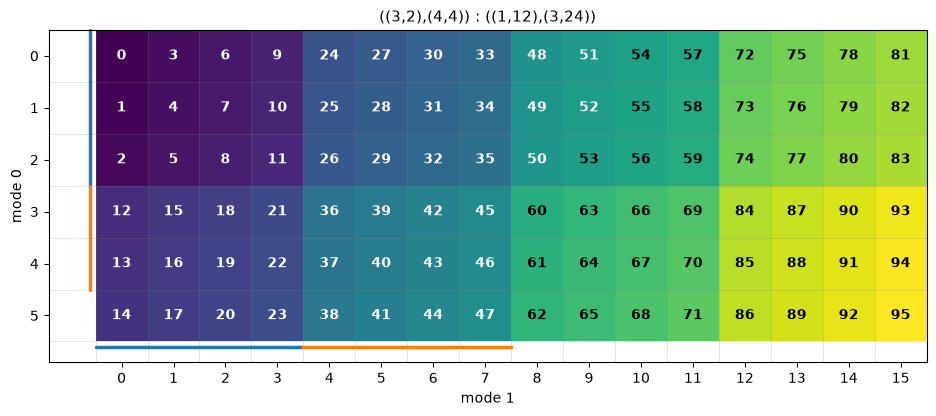

In [79]:
plot_layout(prod)

The next question we want to ask is, what is the largest unit that a swizzle preserves, and what is the largest unit that a swizzle repeats in a 2d layout. Let us swizzle a core matrix 8x16B assume bf16

In [80]:
core_matrix_k_maj = Layout(fl((8,8)), fl((8,1)))
core_matrix_mn_maj = Layout(fl((8,8)), fl((1,8)))
b = 1

<Axes: title={'center': '(8,8) : (8,1)'}, xlabel='mode 1', ylabel='mode 0'>

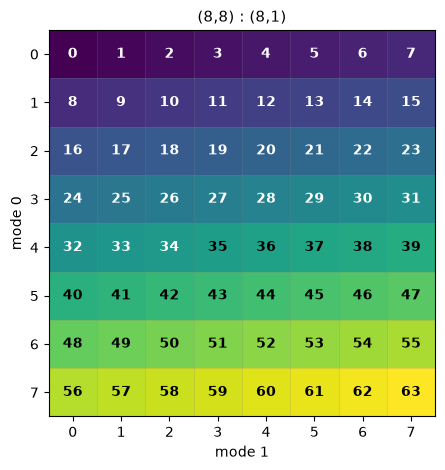

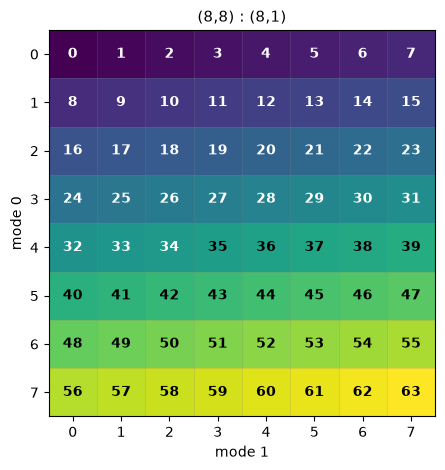

In [81]:
s = Swizzle(b,4,3,2)

core_matrix_k_maj_swiz = make_composed(core_matrix_k_maj, s)
plot_layout(core_matrix_k_maj)
plot_layout(core_matrix_k_maj_swiz)

This makes a lot of sense. the first 4 bits of a byte address are untouched, thats 2^5 - 1 byte addresses not touched, that should be 63, cause I 2^5 = 64, lets work that out, that 2*(2^4) = 2*(4^2) = 32? WHAT? 

In [82]:
def make_swizzle(m,n, b): 
  s = Swizzle(b,4,3,2) 
  L = Layout((m,n), (n,1))
  return make_composed(L, s)
  

In [83]:
X = make_swizzle(16,8,1)

<Axes: title={'center': '(16,8) : (8,1)'}, xlabel='mode 1', ylabel='mode 0'>

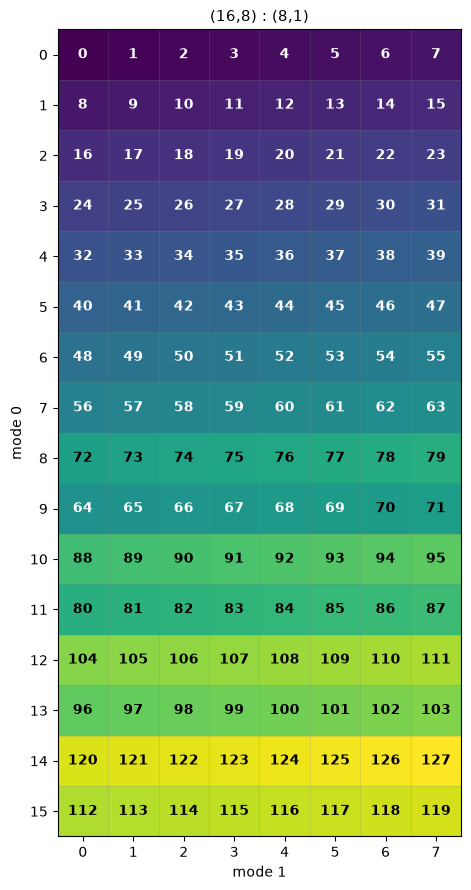

In [84]:
plot_layout(X)

// A generic Swizzle functor
/* 0bxxxxxxxxxxxxxxxYYYxxxxxxxZZZxxxx
 *                               ^--^ MBase is the number of least-sig bits to keep constant
 *                  ^-^       ^-^     BBits is the number of bits in the mask
 *                    ^---------^     SShift is the distance to shift the YYY mask
 *                                       (pos shifts YYY to the right, neg shifts YYY to the left)
 *
 * e.g. Given
 * 0bxxxxxxxxxxxxxxxxYYxxxxxxxxxZZxxx
 * the result is
 * 0bxxxxxxxxxxxxxxxxYYxxxxxxxxxAAxxx where AA = ZZ xor YY


 look at it this way, for positive s_shift, the top [mbase + s_shift, mbase + s_shift + b_bits] bits are taken and xord with the [mbase, mbase + b_bits]. Xoring with 0 will leave things unchaged. 

 Therefore, the first swizzle pattern appears after 2^(mbase + s_shift) byte addresses. 
indeed, then, for all <x,4,3> swizzlers, the firs swizzle pattern appears after 2^(3+4) = 2^7 byte adresses and 2^7 = 2*(2^6) = 2*(4^3) = 2*64 = 128 bytes before the swizzle starts, but notice 128 = 8x16. this has something to do with corematricies. 

The above discussion is about the first swizzle pattern to appear, but each swizzle also has the invariant of 4 bits of m_base, that is 2^4 byte addresses or 2^4*8 bits of data are kept as is. which is again 128 bits, this is what the docs are on about. 

In [85]:
def make_core_matrices(m_iters, k_iters, is_inner_k_major, is_outer_k_major, b_bits,dtype_width): 
  #even though a core_matrix is 16B in the major dimension, a matmul always consumes a 32B k dimension, 
  #which means that whatever the k_iters is, for the k_major case we'll need to double it. 
  #now, for the m_major case, the k dimension is 8 ELEMENTS, which is 8*dtype_width bytes. 
  # if dtype width is 2 then we will fucking make 16k dims per iter, perfect,
  # if dtype width is 4, we'll need to half the m_iters? idk man ffs nothing is core about this corematrix 
  
  n_major_elements = 16//dtype_width
  if is_inner_k_major: 
    if b_bits > 0:
      x = (2**b_bits)*32//dtype_width
      core_mat = Layout((8,x), (x,1))
    else:
      core_mat = Layout((8,n_major_elements), (n_major_elements,1)) 
  else: 
    core_mat = Layout((n_major_elements,8), (1, n_major_elements)) 
  
  if is_outer_k_major: 
    outer_mat = Layout((m_iters,2*k_iters), (2*k_iters,1)) 
  else: 
    outer_mat = Layout((m_iters, 2*k_iters), (1, m_iters)) 
    
  L = layout_algebra.blocked_product(core_mat, outer_mat) 
  swiz = Swizzle(b_bits, 4,3,dtype_width)
  return make_composed(L, swiz), core_mat, outer_mat

In [86]:
m_iters = 2 
k_iters = 2 
is_inner_k_major = True 
is_outer_k_major = False
b_bits = 1
dtype_width = 4

L,core, outer = make_core_matrices(m_iters, k_iters, is_inner_k_major, is_outer_k_major, b_bits, dtype_width)

In [87]:
print(L)
print(core)
print(outer)

ComposedLayout(layout=Layout(shape=((8, 2), (16, 4)), stride=((16, 128), (1, 256))), swizzle=Swizzle(b_bits=1, m_base=4, s_shift=3, element_bytes=4))
Layout(shape=(8, 16), stride=(16, 1))
Layout(shape=(2, 4), stride=(1, 2))


many of my initial hypothesis were wrong. firstly, I dont think the corematrix is 8x16B when there is a swizzle? not fucking sure. actually no, 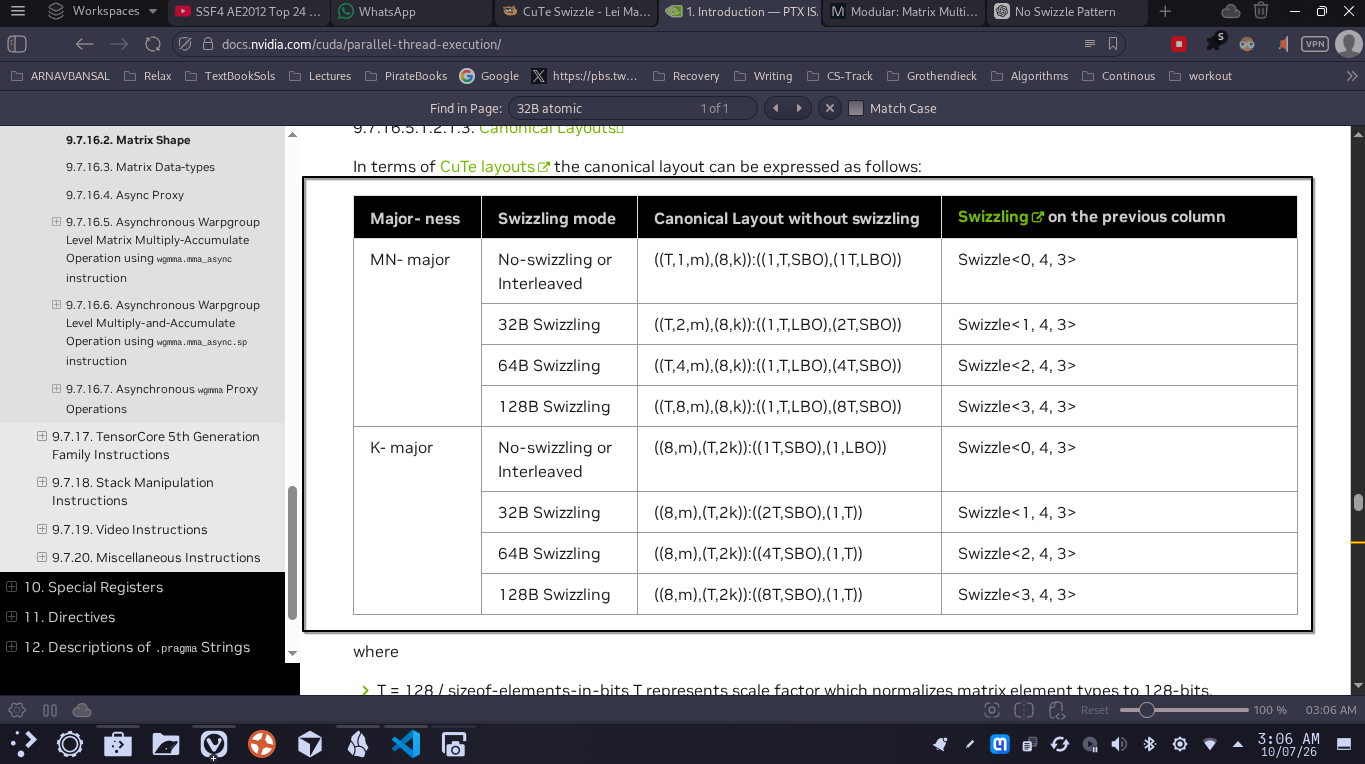

have a look at the above image. 
a blocked product of (x,y):.. x (X,Y).. I(left is tile, right is ITERATOR) results in a shape (x,X),(y,Y)
we see for K major (we will deal with MN major later ffs) (8,m),(T,2k) all throughout. 
Which means, x = 8, y = T, X = m, Y = 2k. 
The only issue is, the blocked product of (x,y): .. x (X,Y): .. is always consistent if the strides are consistent, but clearly in the above picture, the strides are aboslutely different. 
One thing I can do is literally iterpret what the m,k mean over here by looking at the strides. I am sure we can then turn it into the right blocked product. if not then IT ISNT A BLOCKED PRODUCT 

okay, lets look at k-major, no swizzling: 

give a coordinate x into the first mode, and y into the second mode. the first mode is literally turning it into a co-ordinate, that steps through. let us do one thing, let us take a canonical layout and extract modes. In order to even use the abolve layout, we need to know how to calculate m,k, LBO,SBO, which requires knowing the layout LMAO, unless there is a fundamental governing principle. 
Figure 189 K major, 32B swizzling and tf32 type

the strides and related details are as follows:

Exact layout : Swizzle<1,4,3> o ((8,2),(4,4)):((8,64),(1,4))

Canonical Layout :Swizzle<1,4,3> o ((8,m),(T,2k)):((2T,SBO),(1,T))

In [95]:
m = 2 
k = 2 
T = 16//4 #128/32 tf32 
SBO = 64 
L = Layout(((8,m), (T,2*k)),((2*T,SBO), (1,T)))
L_swiz = make_composed(L, Swizzle(1,4,3,4))
def get_blocks(L:ComposedLayout): 
  assert L.rank == 2 
  mode_0 = L.get_mode(0)
  mode_1 = L.get_mode(1)
  modes0 = []
  modes1 = []
  min_len = min(mode_0.length, mode_1.length)
  for i in range(min_len): 
    if (i % 2 == 0):
      modes0.append(mode_0.get_mode(i))
      modes0.append(mode_1.get_mode(i))
    else: 
      modes1.append(mode_0.get_mode(i))
      modes1.append(mode_1.get_mode(i))
      
  swiz = L.swizzle
  return layout_algebra.concatenate(modes0), layout_algebra.concatenate(modes1)
    

<Axes: title={'center': '((8,2),(4,4)) : ((8,64),(1,4))'}, xlabel='mode 1', ylabel='mode 0'>

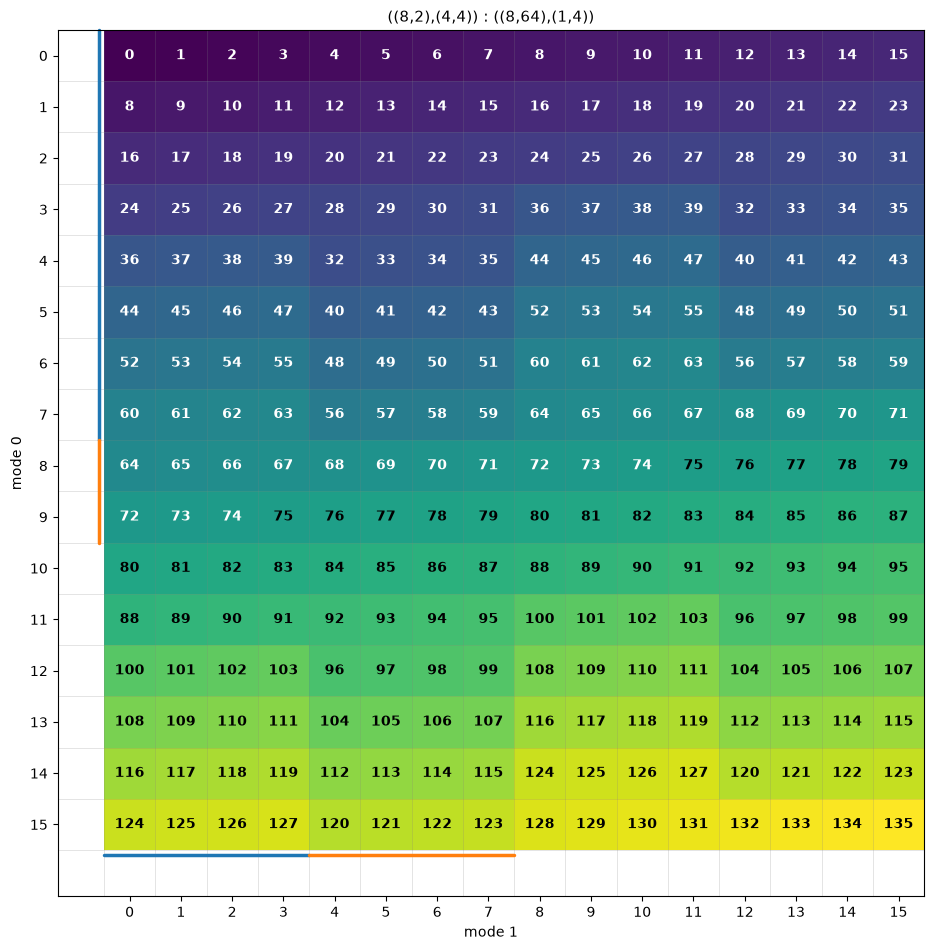

In [96]:
plot_layout(L_swiz)

In [97]:
tile, tiler = get_blocks(L_swiz)

In [98]:
L_swiz

ComposedLayout(layout=Layout(shape=((8, 2), (4, 4)), stride=((8, 64), (1, 4))), swizzle=Swizzle(b_bits=1, m_base=4, s_shift=3, element_bytes=4))

<Axes: title={'center': '(8,4) : (8,1)'}, xlabel='mode 1', ylabel='mode 0'>

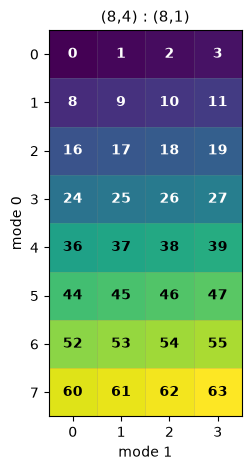

In [92]:
plot_layout(tile)

<Axes: title={'center': '(2,4) : (64,4)'}, xlabel='mode 1', ylabel='mode 0'>

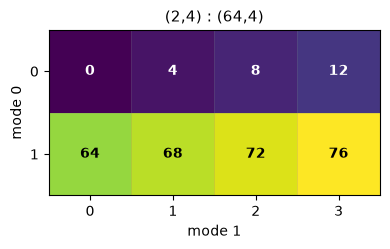

In [99]:

plot_layout(tiler)

In [100]:
X = layout_algebra.blocked_product(tile, tiler)

AssertionError: 

(x,y,z):.. x (X,Y,Z):... -> (x,X), (y,Y), (z,Z)
(x,y):.. x (X,Y,Z):... -> (x,X), ((y,Y), Z)
(x,y,z): .. x (X,Y) : .. -> ((x,X), (y,Y), z) 